In [30]:
# import library
import pandas as pd
import ast
import matplotlib.pyplot as plt
from datasets import load_dataset

# load data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# convert str into datetime 
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

# convert str into list 
df['job_skills'] = df['job_skills'].apply(lambda x : ast.literal_eval(x) if pd.notna(x) else x)

In [31]:
# create new df for specifi job title 
df_data_analyst = df[df['job_title_short'] == 'Data Analyst'].copy()

In [32]:
# convert the month date 
df_data_analyst['job_posted_month'] = df_data_analyst['job_posted_date'].dt.month

In [35]:
# nge pecah job skills nya 
df_data_analyst_exploded = df_data_analyst.explode('job_skills')

In [ ]:
# fill value itu ngubah value yang nan jadi 0
df_data_analyst_pivot =  df_data_analyst_exploded.pivot_table(index='job_posted_month', columns='job_skills', aggfunc='size', fill_value=0)

# kalau kayak gini skill nya kebanyakan listnya 
df_data_analyst_pivot.plot(kind='line')

In [ ]:
# create the total value row
df_data_analyst_pivot.loc['total'] = df_data_analyst_pivot.sum()

# sort descending 
df_data_analyst_pivot = df_data_analyst_pivot[df_data_analyst_pivot.loc['total'].sort_values(ascending=False).index]

# delete the total value 
df_data_analyst_pivot = df_data_analyst_pivot.drop('total')

df_data_analyst_pivot

job_skills,sql,excel,python,tableau,power bi,r,sas,powerpoint,word,sap,...,angular.js,xamarin,gtx,nuxt.js,ovh,esquisse,suse,capacitor,chainer,msaccess
job_posted_month,,,,,,,,,,,,,,,,,,,,,
1,11336,8170,6606,5596,4285,3607,3830,1880,1778,1251,...,2,0,0,1,0,0,0,1,0,0
2,7947,5772,4751,3936,3307,2576,2634,1291,1235,954,...,0,0,0,0,0,0,0,0,0,0
3,7868,5675,4741,4051,3176,2650,2554,1266,1203,892,...,0,1,0,0,0,0,1,0,0,0
4,7553,5496,4557,3776,3106,2399,2598,1190,1177,947,...,0,0,0,0,1,0,0,0,0,0
5,6617,4773,4070,3245,2695,2093,1940,979,957,851,...,0,0,0,0,0,0,0,0,0,1
6,7584,5724,4707,3812,3275,2442,2174,1173,1237,987,...,0,0,0,0,0,0,0,0,0,0
7,7687,5513,4831,3928,3350,2444,2118,1096,1069,996,...,0,0,1,0,0,0,0,0,0,0
8,8823,6482,5576,4533,3859,2975,2560,1332,1298,1117,...,0,0,0,0,0,0,0,0,0,0
9,6829,4886,4229,3446,3118,2146,1880,944,945,852,...,0,0,0,0,0,0,0,0,0,0


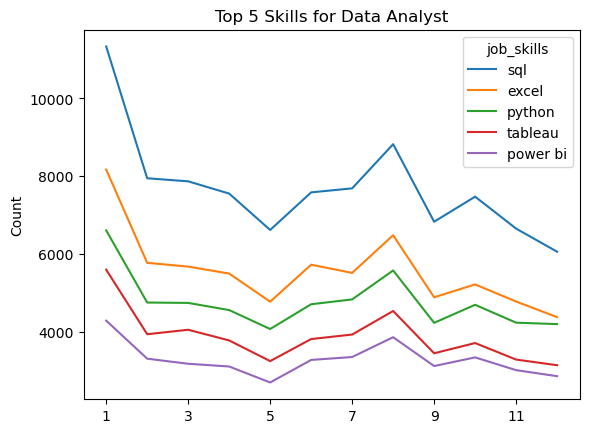

In [51]:
# create plot 
df_data_analyst_pivot.iloc[:, :5].plot(kind='line')
plt.title('Top 5 Skills for Data Analyst')
plt.ylabel('Count')
plt.xlabel('')
plt.show()

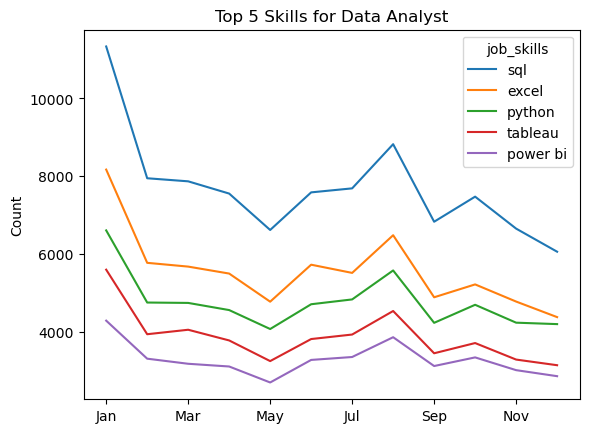

In [52]:
# change the month to string 

df_data_analyst_pivot = df_data_analyst_pivot.reset_index()
df_data_analyst_pivot['job_posted_month_str'] = df_data_analyst_pivot['job_posted_month'].apply(lambda x : pd.to_datetime(x, format='%m').strftime('%b'))
df_data_analyst_pivot = df_data_analyst_pivot.set_index('job_posted_month_str')
df_data_analyst_pivot = df_data_analyst_pivot.drop(columns='job_posted_month')

df_data_analyst_pivot.iloc[:, :5].plot(kind='line')
plt.title('Top 5 Skills for Data Analyst')
plt.ylabel('Count')
plt.xlabel('')
plt.show()